✅ Original Image Selected: C:/Users/Priyanka/Documents/dipProject/og.jpg
✅ Forged Image Selected: C:/Users/Priyanka/Documents/dipProject/forge.jpg


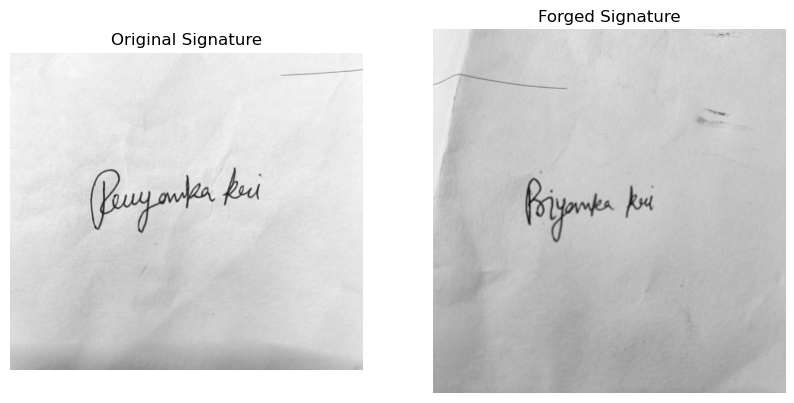

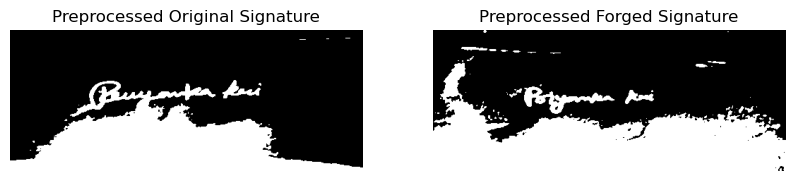

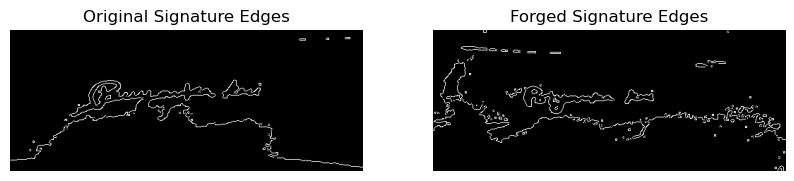


🧐 Mean Squared Error (MSE): 0.04
✅ The signatures are similar. The signature is likely AUTHENTIC.


In [1]:
import cv2
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

# Function to open file dialog properly in Jupyter
def select_image(title="Select an Image"):
    root = tk.Tk()
    root.withdraw()  # Hide root window
    root.call('wm', 'attributes', '.', '-topmost', True)  # Bring dialog to front
    file_path = filedialog.askopenfilename(title=title,
                                           filetypes=[("Image files", ".jpg;.png;*.jpeg")])
    return file_path

# Select original signature
original_path = select_image("Select the Original Signature Image")
if original_path:
    print(f"✅ Original Image Selected: {original_path}")
else:
    print("❌ No Original Signature selected.")
    exit()  # Stop execution if no image is selected

# Select forged signature
forged_path = select_image("Select the Forged Signature Image")
if forged_path:
    print(f"✅ Forged Image Selected: {forged_path}")
else:
    print("❌ No Forged Signature selected.")
exit()

# Load both images
original_img = cv2.imread(original_path, 0)  # Read as grayscale
forged_img = cv2.imread(forged_path, 0)  # Read as grayscale

# Check if images are loaded
if original_img is None or forged_img is None:
    print("❌ Error: One or both images could not be loaded. Check the file format.")
else:
    # Display both images side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_img, cmap="gray")
    axes[0].set_title("Original Signature")
    axes[0].axis("off")

    axes[1].imshow(forged_img, cmap="gray")
    axes[1].set_title("Forged Signature")
    axes[1].axis("off")

    plt.show()
#import cv2
import numpy as np
#import matplotlib.pyplot as plt

def preprocess_image(image_path):
    # Load the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize both images to the same size (optional)
    img = cv2.resize(img, (500, 200))  # Adjust size as needed
    
    # Apply Gaussian blur to reduce noise
    img = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Convert image to binary (black & white)
    _, binary_img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    return binary_img

# Apply preprocessing to both images
original_preprocessed = preprocess_image(original_path)
forged_preprocessed = preprocess_image(forged_path)

# Display preprocessed images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_preprocessed, cmap="gray")
axes[0].set_title("Preprocessed Original Signature")
axes[0].axis("off")

axes[1].imshow(forged_preprocessed, cmap="gray")
axes[1].set_title("Preprocessed Forged Signature")
axes[1].axis("off")

plt.show()
def edge_detection(image):
    edges = cv2.Canny(image, 50, 150)  # Canny Edge Detection
    return edges

# Extract edges
original_edges = edge_detection(original_preprocessed)
forged_edges = edge_detection(forged_preprocessed)

# Display edge-detected images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_edges, cmap="gray")
axes[0].set_title("Original Signature Edges")
axes[0].axis("off")

axes[1].imshow(forged_edges, cmap="gray")
axes[1].set_title("Forged Signature Edges")
axes[1].axis("off")

plt.show()
#import numpy as np

# Function to calculate Mean Squared Error (MSE) between two images
def mse(image1, image2):
    return np.mean((image1 - image2) ** 2)

# Compute MSE between the two edge-detected images
mse_value = mse(original_edges, forged_edges)

# Print MSE result
print(f"\n🧐 Mean Squared Error (MSE): {mse_value:.2f}")

# Decision based on threshold
threshold = 500  # Adjust based on testing
if mse_value < threshold:
    print("✅ The signatures are similar. The signature is likely AUTHENTIC.")
else:
    print("❌ The signatures are different. The signature is likely FORGED.")